Fitting 3 folds for each of 16 candidates, totalling 48 fits
Accuracy: 0.9470
Log Loss (pérdida logarítmica): 0.1492
AUC: 0.9444
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      9716
           1       0.82      0.47      0.59       881

    accuracy                           0.95     10597
   macro avg       0.88      0.73      0.78     10597
weighted avg       0.94      0.95      0.94     10597



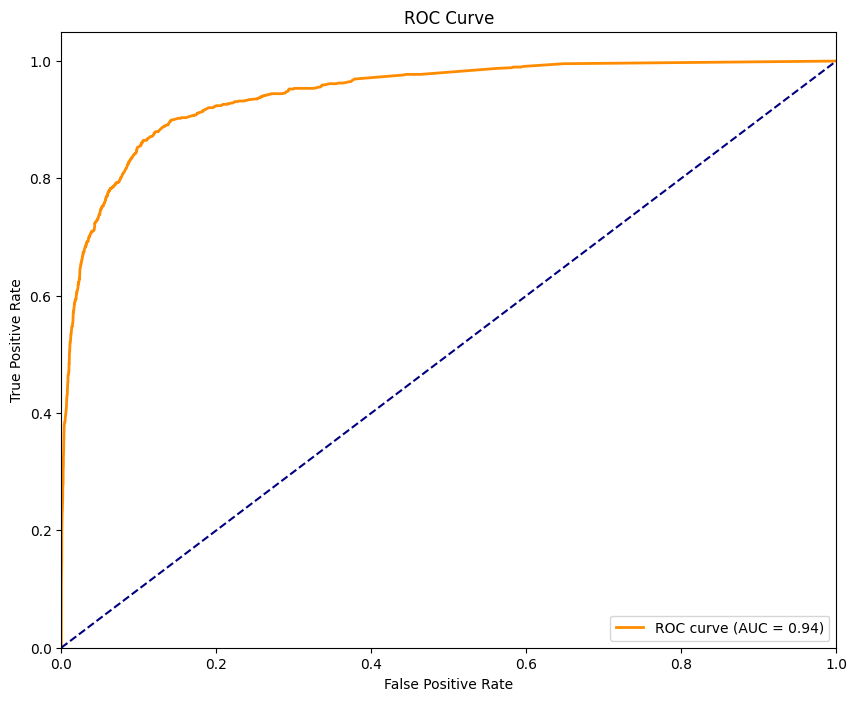

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, classification_report

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Dividir los datos en entrenamiento y prueba
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir el pipeline para MLPClassifier con escalador
mlp_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', MLPClassifier(alpha=0.001, learning_rate_init=0.1, random_state=42))
])

# Crear el StackingClassifier con XGBClassifier como modelo final
stacking_model = StackingClassifier(
    estimators=[
        ('mlp_pipeline', mlp_pipeline),  # MLPClassifier con escalador
        ('xgb', XGBClassifier(random_state=42))  # XGBClassifier como segundo modelo
    ],
    final_estimator=XGBClassifier(random_state=42),  # XGBoost como el modelo final
    cv=5
)

# Definir parámetros para GridSearch
param_grid = {
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__max_depth': [5, 10],
    'final_estimator__learning_rate': [0.01, 0.1],  # Para XGBoost final
    'final_estimator__n_estimators': [100, 200],
}

# Configurar GridSearchCV
grid_search = GridSearchCV(stacking_model, param_grid, cv=3, scoring='roc_auc', verbose=3, n_jobs=-1)

# Entrenar el modelo
grid_search.fit(X_train, y_train)

# Evaluar el mejor modelo
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)
y_pred_proba = best_model.predict_proba(X_val)[:, 1]

# Métricas de evaluación
accuracy = accuracy_score(y_val, y_pred)
logloss = log_loss(y_val, y_pred_proba)
auc = roc_auc_score(y_val, y_pred_proba)

# Mostrar resultados
print(f"Accuracy: {accuracy:.4f}")
print(f"Log Loss (pérdida logarítmica): {logloss:.4f}")
print(f"AUC: {auc:.4f}")
print(classification_report(y_val, y_pred))

# Graficar la curva ROC
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [3]:
import pandas as pd
from datetime import datetime

# Cargar el archivo de prueba (ajusta la ruta si es necesario)
test_data = pd.read_csv('hoteles-prueba-limpio-normalizado.csv')

# Extraer la columna "id" y preparar los datos para predicción
test_ids = test_data['id']
X_test_data = test_data.drop(columns=['id'])

# Generar las probabilidades de predicción usando el mejor modelo obtenido por GridSearchCV (best_model)
y_pred_proba_test = best_model.predict_proba(X_test_data)[:, 1]

# Crear el archivo con timestamp
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M")
file_name = f'kaggle_submission_{timestamp}.csv'
kaggle_submission = pd.DataFrame({'id': test_ids, 'prob': y_pred_proba_test})

# Guardar el archivo para Kaggle
kaggle_submission.to_csv(file_name, index=False)

print(f"Archivo '{file_name}' creado con éxito para Kaggle.")

Archivo 'kaggle_submission_2024_10_19_15_10.csv' creado con éxito para Kaggle.
